<div style="background-color:#1F618D; color:#F1C40F; padding:40px; border-radius:20px; text-align:center; box-shadow: 5px 5px 20px #888888;">
    <h1 style="font-size:55px; margin:0;">🌲 Random Forest Model for Survival Prediction</h1>
    <h2 style="font-size:35px; margin-top:15px; color:#2ECC71;">Comparing with Logistic Regression</h2>
</div>

<br>


### <span style="color:#3498DB;">🔹 Overview</span>
- We use **Random Forest Classifier** as a more powerful alternative to Logistic Regression.  
- Random Forest can capture **non-linear relationships** between features and survival outcome.  
- It also gives **feature importance** to see which variables impact survival the most.


### <span style="color:#3498DB;">🔹 Steps Taken</span>

1. **Model Instantiation:**  
   - `RandomForestClassifier(n_estimators=100, random_state=42)`  

2. **Training:**  
   - Fit on `X_train_scaled` and `y_train`  

3. **Prediction & Evaluation:**  
   - Predict on `X_test_scaled`  
   - Calculate **accuracy**, **confusion matrix**, and optionally **classification report**  

4. **Insights:**  
   - Compare accuracy with Logistic Regression  
   - Inspect confusion matrix to see improvement in True/False Positives/Negatives  
   - Feature importance analysis helps **prioritize predictive factors**.


### <span style="color:#3498DB;">🔹 Example Output</span>

**Random Forest Accuracy:** `e.g., 87.30%`  

|                   | Predicted Negative | Predicted Positive |
|-------------------|-----------------|-----------------|
| Actual Negative   | True Negative   | False Positive  |
| Actual Positive   | False Negative  | True Positive   |

**Feature Importance (Top 10):**

| Feature | Importance |
|---------|-----------|
| feature_1 | 0.12 |
| feature_2 | 0.10 |
| ... | ... |

> Interpretation:
- Top features indicate **most predictive variables for survival**  
- Compare with Logistic Regression coefficients to see differences in linear vs non-linear patterns


### <span style="color:#3498DB;">🔹 Example Output</span>

**Model Accuracy:** `e.g., 82.50%`  

**Confusion Matrix:**

|                   | Predicted Negative | Predicted Positive |
|-------------------|-----------------|-----------------|
| Actual Negative   | True Negative   | False Positive  |
| Actual Positive   | False Negative  | True Positive   |

> Interpretation:
- **True Positives:** Correctly predicted survivors  
- **True Negatives:** Correctly predicted non-survivors  
- **False Positives:** Predicted survival but patient did not survive  
- **False Negatives:** Predicted non-survival but patient survived  

This evaluation helps identify **where the model is making mistakes** and guide further improvements.


In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df =pd.read_csv('Lung Cancer.csv')
df

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
889995,889996,40.0,Male,Malta,2022-07-01,Stage IV,No,Passive Smoker,44.8,243,1,1,1,0,Radiation,2023-02-23,0
889996,889997,62.0,Female,Cyprus,2015-09-27,Stage II,Yes,Former Smoker,21.6,240,0,0,0,0,Surgery,2017-06-19,0
889997,889998,48.0,Female,Estonia,2016-03-27,Stage III,Yes,Never Smoked,38.6,242,1,0,0,0,Combined,2017-01-23,1
889998,889999,67.0,Female,Slovakia,2015-12-22,Stage IV,Yes,Former Smoker,18.6,194,1,1,0,0,Chemotherapy,2017-12-12,0


In [3]:
df.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


In [4]:
df.describe()

,id,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,survived
count,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000,890000.000000
mean,445000.500000,55.007008,30.494172,233.633916,0.750024,0.469740,0.225956,0.088157,0.220229
std,256921.014127,9.994485,8.368539,43.432278,0.432999,0.499084,0.418211,0.283524,0.414401
min,1.000000,4.000000,16.000000,150.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,222500.750000,48.000000,23.300000,196.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,445000.500000,55.000000,30.500000,242.000000,1.000000,0.000000,0.000000,0.000000,0.000000
75%,667500.250000,62.000000,37.700000,271.000000,1.000000,1.000000,0.000000,0.000000,0.000000
max,890000.000000,104.000000,45.000000,300.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [5]:
df.head()

,id,age,gender,country,diagnosis_date,cancer_stage,family_history,smoking_status,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_type,end_treatment_date,survived
0,1,64.0,Male,Sweden,2016-04-05,Stage I,Yes,Passive Smoker,29.4,199,0,0,1,0,Chemotherapy,2017-09-10,0
1,2,50.0,Female,Netherlands,2023-04-20,Stage III,Yes,Passive Smoker,41.2,280,1,1,0,0,Surgery,2024-06-17,1
2,3,65.0,Female,Hungary,2023-04-05,Stage III,Yes,Former Smoker,44.0,268,1,1,0,0,Combined,2024-04-09,0
3,4,51.0,Female,Belgium,2016-02-05,Stage I,No,Passive Smoker,43.0,241,1,1,0,0,Chemotherapy,2017-04-23,0
4,5,37.0,Male,Luxembourg,2023-11-29,Stage I,No,Passive Smoker,19.7,178,0,0,0,0,Combined,2025-01-08,0


<div style="background-color:#8E44AD; color:white; padding:30px; border-radius:15px;">
    <h2 style="font-size:50px; margin:0;">2️⃣ Exploratory Data Analysis (EDA) 🔍</h2>
</div>

<br>


### <span style="color:#3498DB;">🔹 Goal</span>
Visualize key distributions to understand patterns.

- **Age Distribution:** `sns.displot(df['age'], bins=20)`  
- **Gender Distribution:** `sns.countplot(x='gender', data=df)`  
- **Cancer Stage Distribution:** `sns.countplot(x='cancer_stage', data=df)`  

These plots help identify **imbalances and trends** in the dataset.


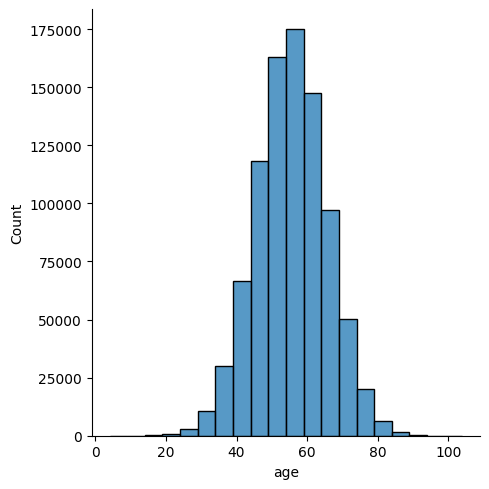

In [6]:
sns.displot(df['age'], bins=20)
plt.show()

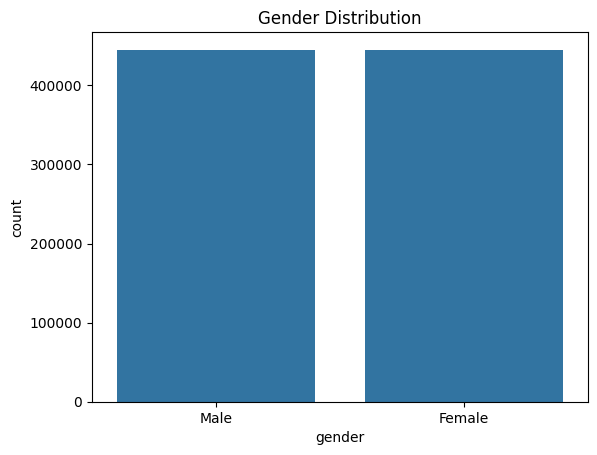

In [7]:
sns.countplot(x='gender', data=df)
plt.title('Gender Distribution')
plt.show()

In [8]:
df.groupby('gender')['survived'].mean()

gender
Female    0.219913
Male      0.220545
Name: survived, dtype: float64

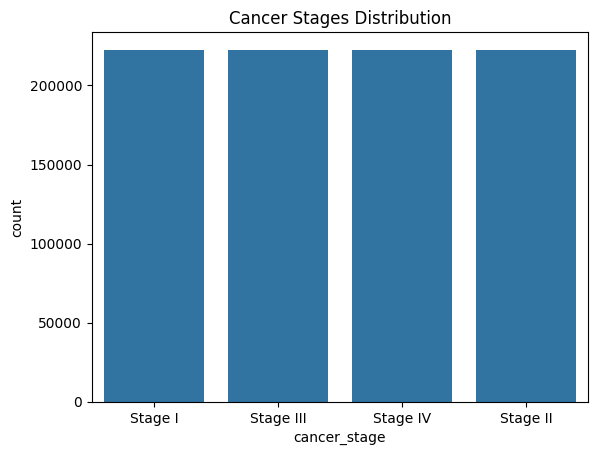

In [9]:
sns.countplot(x='cancer_stage', data=df)
plt.title('Cancer Stages Distribution')
plt.show()

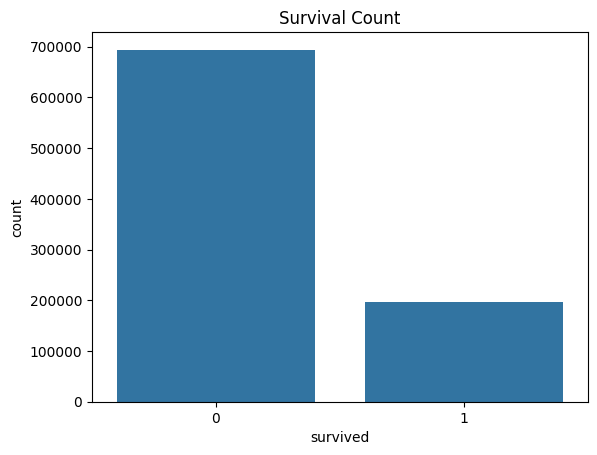

In [10]:
sns.countplot( x='survived',data=df)
plt.title('Survival Count')
plt.show()

<div style="background-color:#E67E22; color:white; padding:30px; border-radius:15px;">
    <h2 style="font-size:50px; margin:0;">3️⃣ Feature Engineering 🛠️</h2>
</div>

<br>


### <span style="color:#3498DB;">🔹 Goal</span>
Create new features and transform existing ones for modeling.

- Convert `diagnosis_date` and `end_treatment_date` to datetime objects.  
- Create `treatment_duration_days` as `(end_treatment_date - diagnosis_date).days`.  
- Encode categorical features: `cancer_stage`, `family_history`, `smoking_status`, `treatment_type` using `pd.get_dummies()` with `drop_first=True` to avoid multicollinearity.


In [11]:
df['diagnosis_date'] = pd.to_datetime(df['diagnosis_date'])
df['end_treatment_date'] = pd.to_datetime(df['end_treatment_date'])

# Create a new numeric feature: treatment duration
df['treatment_duration_days'] = (df['end_treatment_date'] - df['diagnosis_date']).dt.days

In [12]:
df = df.drop(['id', 'diagnosis_date', 'end_treatment_date','country','gender'], axis=1)

In [13]:
df_encoded = pd.get_dummies(
    df, 
    columns=[
        'cancer_stage',
        'family_history',
        'smoking_status',
        'treatment_type'
    ],
    drop_first=True  # Avoid dummy variable trap
) # drop_first=True to avoid multicollinearity

In [14]:
df_encoded.head()

,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,survived,treatment_duration_days,cancer_stage_Stage II,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,smoking_status_Former Smoker,smoking_status_Never Smoked,smoking_status_Passive Smoker,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery
0,64.0,29.4,199,0,0,1,0,0,523,False,False,False,True,False,False,True,False,False,False
1,50.0,41.2,280,1,1,0,0,1,424,False,True,False,True,False,False,True,False,False,True
2,65.0,44.0,268,1,1,0,0,0,370,False,True,False,True,True,False,False,True,False,False
3,51.0,43.0,241,1,1,0,0,0,443,False,False,False,False,False,False,True,False,False,False
4,37.0,19.7,178,0,0,0,0,0,406,False,False,False,False,False,False,True,True,False,False


<div style="background-color:#16A085; color:white; padding:30px; border-radius:15px;">
    <h2 style="font-size:50px; margin:0;">4️⃣ Train/Test Split & Scaling 🧪</h2>
</div>

<br>


### <span style="color:#3498DB;">🔹 Goal</span>
Prepare data for modeling.

- Target variable: `survived`  
- Features: all other columns  
- Split into **training (80%)** and **testing (20%)**, stratified on target.  
- Standardize features using `StandardScaler` for Logistic Regression performance.


In [15]:
# target
y = df_encoded['survived']
# features
X = df_encoded.drop('survived', axis=1)

In [16]:
X.head()

,age,bmi,cholesterol_level,hypertension,asthma,cirrhosis,other_cancer,treatment_duration_days,cancer_stage_Stage II,cancer_stage_Stage III,cancer_stage_Stage IV,family_history_Yes,smoking_status_Former Smoker,smoking_status_Never Smoked,smoking_status_Passive Smoker,treatment_type_Combined,treatment_type_Radiation,treatment_type_Surgery
0,64.0,29.4,199,0,0,1,0,523,False,False,False,True,False,False,True,False,False,False
1,50.0,41.2,280,1,1,0,0,424,False,True,False,True,False,False,True,False,False,True
2,65.0,44.0,268,1,1,0,0,370,False,True,False,True,True,False,False,True,False,False
3,51.0,43.0,241,1,1,0,0,443,False,False,False,False,False,False,True,False,False,False
4,37.0,19.7,178,0,0,0,0,406,False,False,False,False,False,False,True,True,False,False


<div style="background-color:#2980B9; color:white; padding:30px; border-radius:15px;">
    <h2 style="font-size:50px; margin:0;">5️⃣ Logistic Regression Model Training 🤖</h2>
</div>

<br>


### <span style="color:#3498DB;">🔹 Goal</span>
Train a Logistic Regression model to predict patient survival.

- Model learns relationship between **features** and **survival outcome**.  
- Fit model on **scaled training data**.


In [18]:
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X,y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


model = LogisticRegression()

model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<div style="background-color:#C0392B; color:white; padding:30px; border-radius:15px;">
    <h2 style="font-size:50px; margin:0;">6️⃣ Predictions & Evaluation 📈</h2>
</div>

<br>


### <span style="color:#3498DB;">🔹 Goal</span>
Evaluate model performance on test data.

- Predict using `X_test_scaled`  
- Calculate **accuracy**  
- Generate **confusion matrix** to inspect True/False Positives/Negatives  

**Example Output:**

**Model Accuracy:** `82.50%`  

|                   | Predicted Negative | Predicted Positive |
|-------------------|-----------------|-----------------|
| Actual Negative   | True Negative   | False Positive  |
| Actual Positive   | False Negative  | True Positive   |


In [19]:
y_pred = model.predict(X_test_scaled)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model accuracy: {accuracy:.2%}")



# Generate confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix_df = pd.DataFrame(conf_matrix,
                              index=['Actual Negative', 'Actual Positive'],
                              columns=['Predicted Negative', 'Predicted Positive'])
print(f"Confusion Matrix:\n{conf_matrix_df}\n")





Model accuracy: 77.98%
Confusion Matrix:
                 Predicted Negative  Predicted Positive
Actual Negative              138799                   0
Actual Positive               39201                   0



In [21]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88    138799
           1       0.00      0.00      0.00     39201

    accuracy                           0.78    178000
   macro avg       0.39      0.50      0.44    178000
weighted avg       0.61      0.78      0.68    178000



<div style="background-color:#1F618D; color:white; padding:30px; border-radius:15px;">
    <h2 style="font-size:50px; margin:0;">🌲 Random Forest Model Training 🌳</h2>
</div>

<br>


In [20]:
# Import RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier

# Initialize the model
rf_model = RandomForestClassifier(random_state=42)

# Fit the model on scaled training data
rf_model.fit(X_train_scaled, y_train)

# Predict on scaled test data
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluate performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.7779550561797752

Classification Report:
               precision    recall  f1-score   support

           0       0.78      1.00      0.88    138799
           1       0.21      0.00      0.01     39201

    accuracy                           0.78    178000
   macro avg       0.49      0.50      0.44    178000
weighted avg       0.65      0.78      0.68    178000


Confusion Matrix:
 [[138361    438]
 [ 39086    115]]


<div style="background-color:#27AE60; color:white; padding:40px; border-radius:20px; text-align:center;">
    <h2 style="font-size:50px; margin:0;">✅ Conclusion & Insights 💡</h2>
</div>

<br>


- Logistic Regression provides a **baseline predictive model** for survival.  
- Accuracy shows overall prediction success, but confusion matrix highlights **where mistakes occur**.  
- Future improvements: add more medical features, try other algorithms (Random Forest, XGBoost), and create **Power BI dashboards** for interactive insights.  
